<a href="https://colab.research.google.com/github/christy5165/Denoising_Autoencoder.ipynb/blob/main/GAN_WK_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu
Average network found !


Using cache found in /root/.cache/torch/hub/facebookresearch_pytorch_GAN_zoo_hub


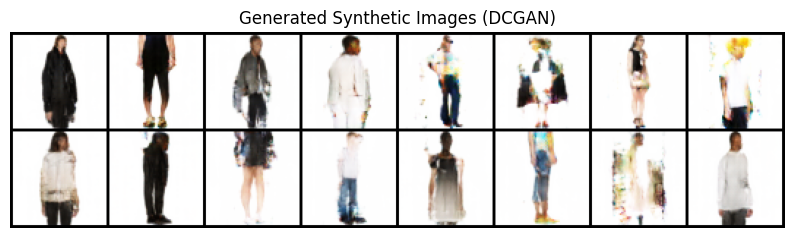

In [3]:
# 1. IMPORT LIBRARIES
import torch
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np

# 2. LOAD PRE-TRAINED GAN MODEL
# We are using a DCGAN model trained on the CelebA (faces) dataset from PyTorch Hub
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# This line downloads the model architecture and the pre-trained weights
model = torch.hub.load('facebookresearch/pytorch_GAN_zoo:hub', 'DCGAN', pretrained=True, use_gpu=(torch.cuda.is_available()))

# 3. GENERATE SYNTHETIC IMAGES
# We create 'noise' which the Generator uses as a starting point
num_images = 16
# Manually create the random noise (100 is the standard size for DCGAN)
noise = torch.randn(num_images, 120, 1, 1, device=device)

# The Generator turns the noise into images (Inference mode)
with torch.no_grad():
    generated_images = model.test(noise)

# 4. VISUALIZE THE RESULTS
# We move the data to the CPU and format it into a grid for display
generated_images = generated_images.to('cpu')

plt.figure(figsize=(10,10))
plt.axis("off")
plt.title("Generated Synthetic Images (DCGAN)")
# make_grid helps arrange the 16 images into a neat table
grid_img = vutils.make_grid(generated_images, padding=2, normalize=True)
plt.imshow(np.transpose(grid_img, (1, 2, 0)))
plt.show()